# EDA – Exploratory Data Analysis

Tento notebook funguje pro **XAUUSD i EURUSD**, pro **CSV i Parquet** soubory.  
**Nastav `DATA_PATH` níže a spusť buňky postupně od shora dolů.**

In [23]:
import sys
sys.path.insert(0, '..')

# Vynutit znovunačtení modulů (nutné při editaci src/ bez restartu kernelu)
import importlib
import src.data_loader as _dl_module
importlib.reload(_dl_module)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data_loader import load_data, create_target, drop_leaky_and_meta_columns

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='darkgrid')

# --- Nastav cestu k datovému souboru (.parquet nebo .csv) ---
DATA_PATH = '../data/xauusd.parquet'

_suffix = Path(DATA_PATH).suffix.lower()
print(f'Soubor: {DATA_PATH}  |  Formát: {_suffix}')

Soubor: ../data/xauusd.parquet  |  Formát: .parquet


## 1. Načtení dat

In [24]:
df_raw = load_data(DATA_PATH)
df = create_target(df_raw)          # použije label_h1 (pokud existuje) nebo Close shift
df = drop_leaky_and_meta_columns(df)

print(f'Shape: {df.shape}')
print(f'Období: {df.index.min().date()} → {df.index.max().date()}')
print(f'Datové typy: {df.dtypes.value_counts().to_dict()}')
df.head(3)

ArrowKeyError: No type extension with name arrow.py_extension_type found

## 2. Základní statistiky

In [ ]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
dow,4999.000000,1.925585,1.452345,0.000000,1.000000,2.000000,3.000000,6.000000
open,4999.000000,1121.370884,19.884845,1081.700000,1099.705000,1126.000000,1135.700000,1160.340000
high,4999.000000,1121.880384,19.854344,1082.420000,1100.150000,1126.600000,1136.300000,1161.630000
low,4999.000000,1120.836223,19.920909,1080.860000,1099.245000,1125.550000,1135.220000,1158.920000
close,4999.000000,1121.376385,19.888654,1081.270000,1099.685000,1126.070000,1135.725000,1160.330000
atr14,4993.000000,1.059024,0.452037,0.147143,0.737143,0.962857,1.262857,3.357143
f30_dist_ema9_atr,4999.000000,-0.001022,0.923875,-6.206696,-0.543615,0.000000,0.526095,6.206377
f30_mtf_M15_pos_in_range,4999.000000,0.510858,0.307718,0.000000,0.235294,0.514019,0.785714,1.000000
f30_close_vs_ema9,4999.000000,-0.000007,0.000995,-0.007940,-0.000461,0.000000,0.000439,0.011788
f30_mtf_H1_pos_in_range,4999.000000,0.509603,0.297042,0.000000,0.248637,0.519594,0.770632,1.000000


## 3. Balance targetu (Long vs Short)

target
0    2577
1    2422
Name: count, dtype: int64

Poměr Long/Short: 0.940


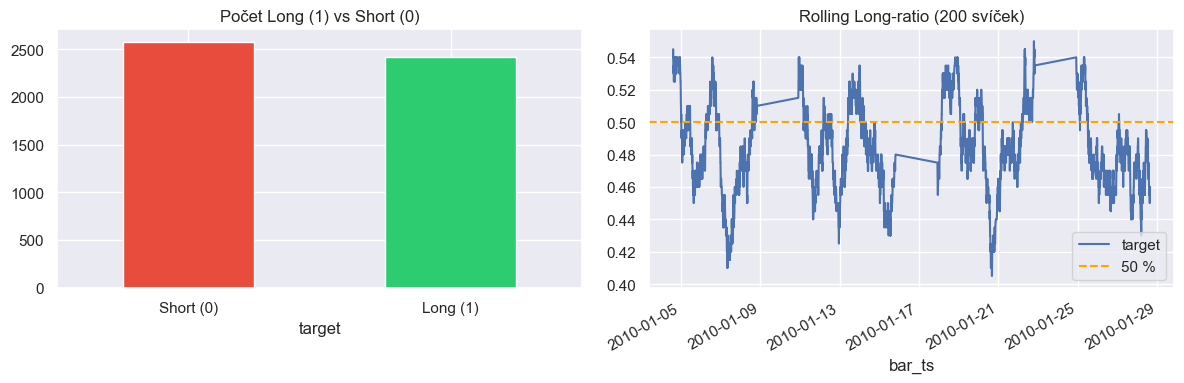

In [ ]:
target_counts = df['target'].value_counts()
print(target_counts)
print(f'\nPoměr Long/Short: {target_counts[1]/target_counts[0]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts.plot.bar(ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Počet Long (1) vs Short (0)')
axes[0].set_xticklabels(['Short (0)', 'Long (1)'], rotation=0)

# Rolling balance po čase (kloubí se trh?)
df['target'].rolling(200).mean().plot(ax=axes[1])
axes[1].axhline(0.5, color='orange', linestyle='--', label='50 %')
axes[1].set_title('Rolling Long-ratio (200 svíček)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Chybějící hodnoty (NaN)

Sloupce s NaN (66):


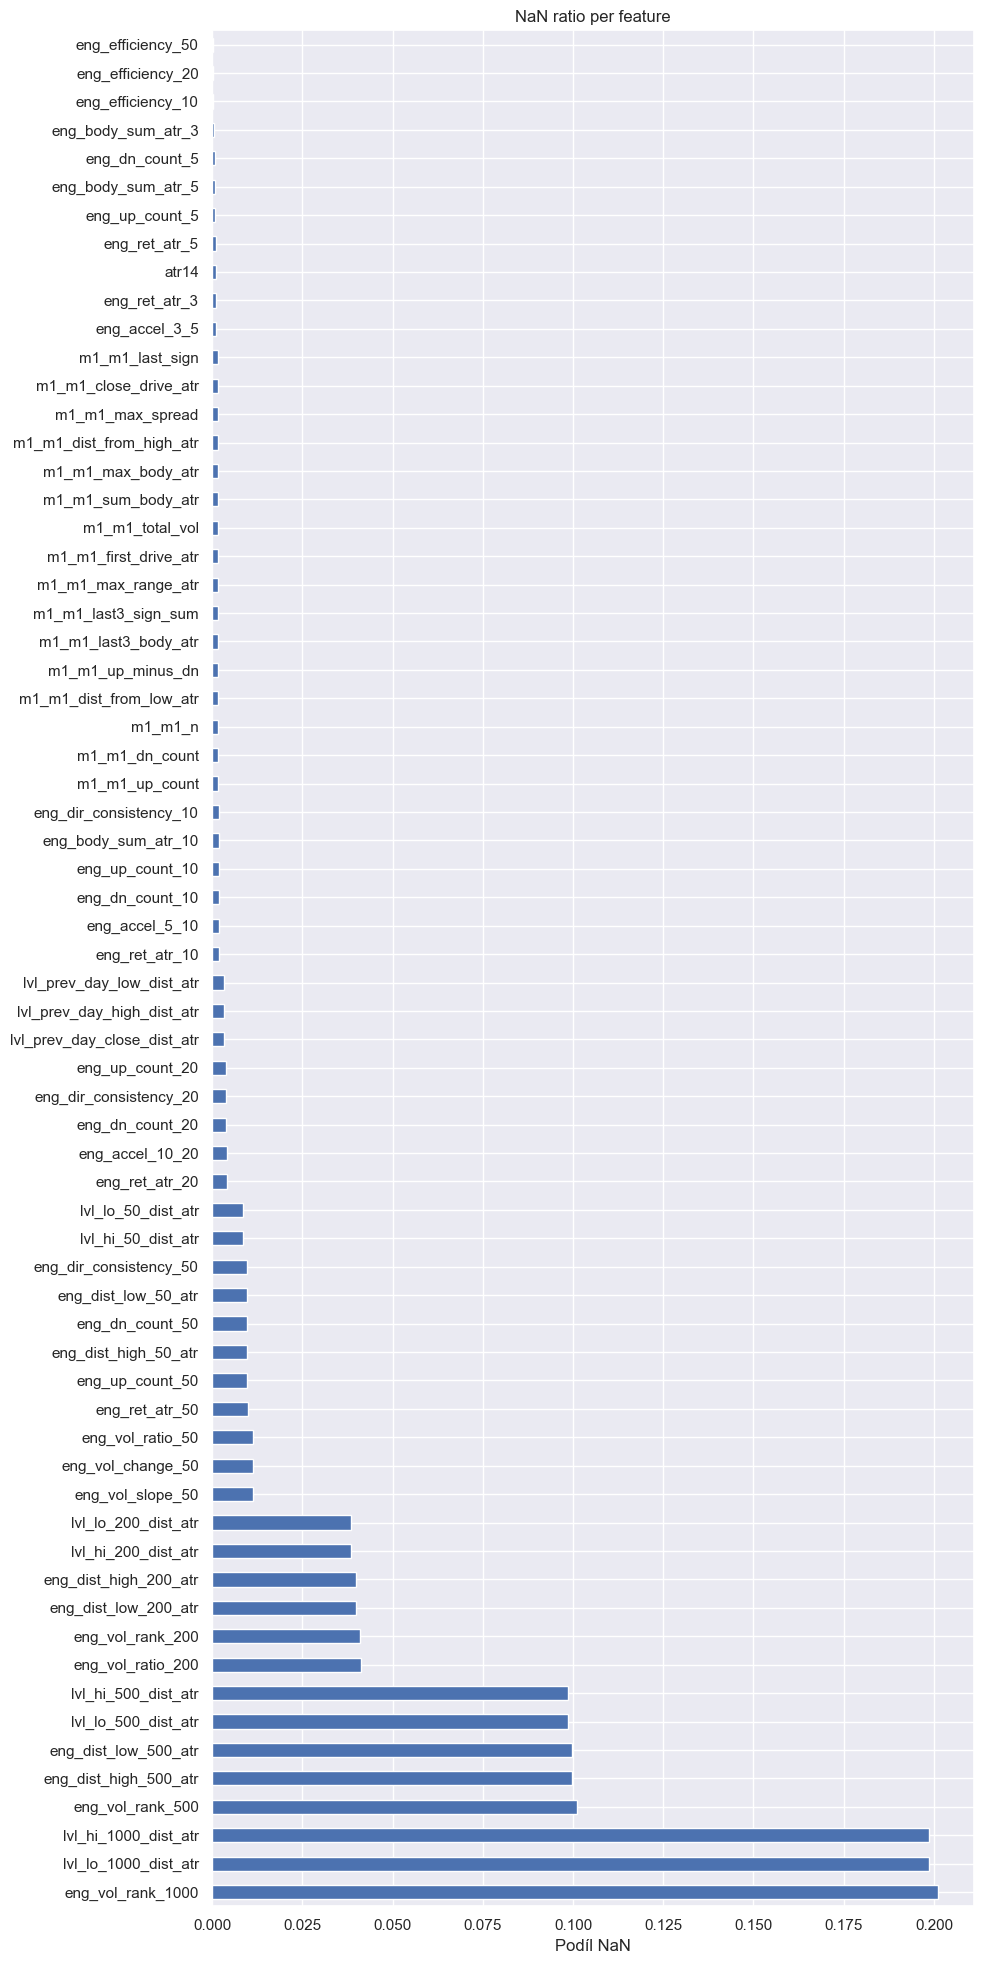

In [ ]:
nan_pct = df.isna().mean().sort_values(ascending=False)
nan_pct = nan_pct[nan_pct > 0]

if len(nan_pct) == 0:
    print('Žádné NaN hodnoty!')
else:
    print(f'Sloupce s NaN ({len(nan_pct)}):')
    nan_pct.plot.barh(figsize=(10, max(4, len(nan_pct) * 0.3)))
    plt.xlabel('Podíl NaN')
    plt.title('NaN ratio per feature')
    plt.tight_layout()
    plt.show()

## 5. Close cena + ATR v čase

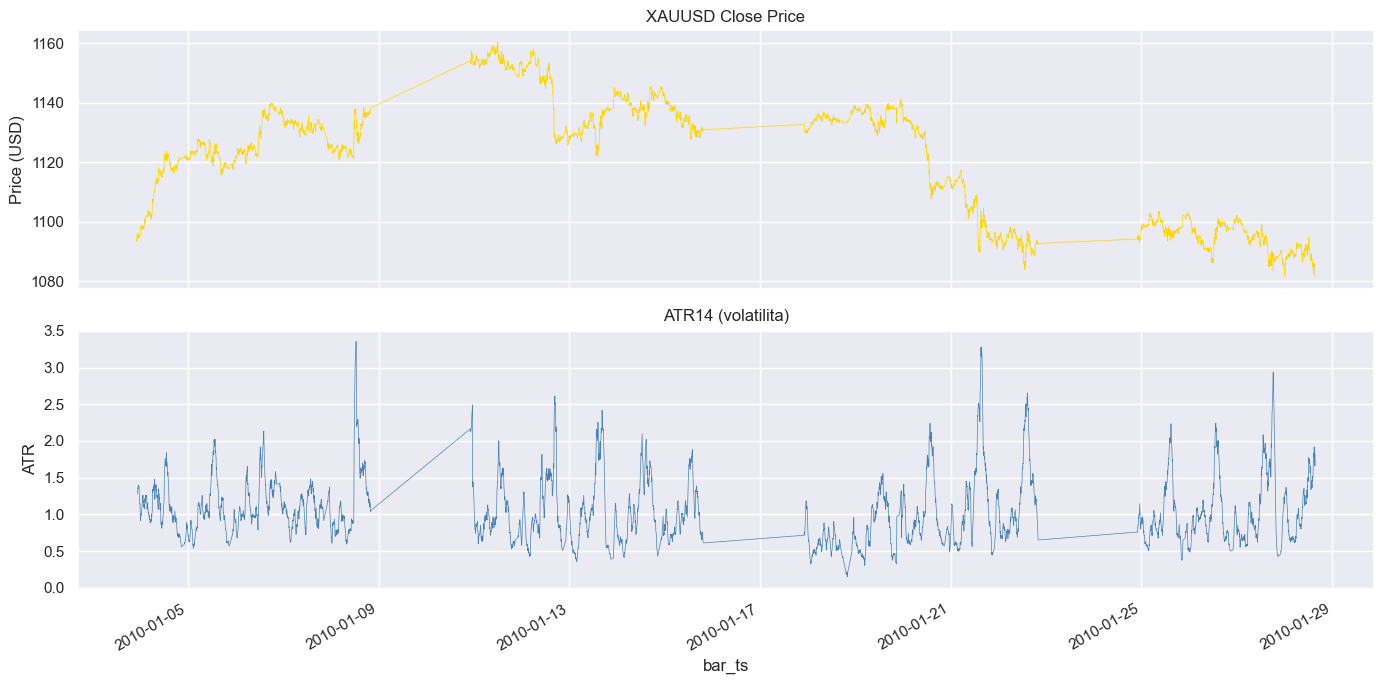

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

df['close'].plot(ax=ax1, color='gold', linewidth=0.5)
ax1.set_title('XAUUSD Close Price')
ax1.set_ylabel('Price (USD)')

df['atr14'].plot(ax=ax2, color='steelblue', linewidth=0.5)
ax2.set_title('ATR14 (volatilita)')
ax2.set_ylabel('ATR')

plt.tight_layout()
plt.show()

## 6. Korelační matice (Top 30 features s targetem)

f:\MojeProjekty\GoldTrading\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
f:\MojeProjekty\GoldTrading\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


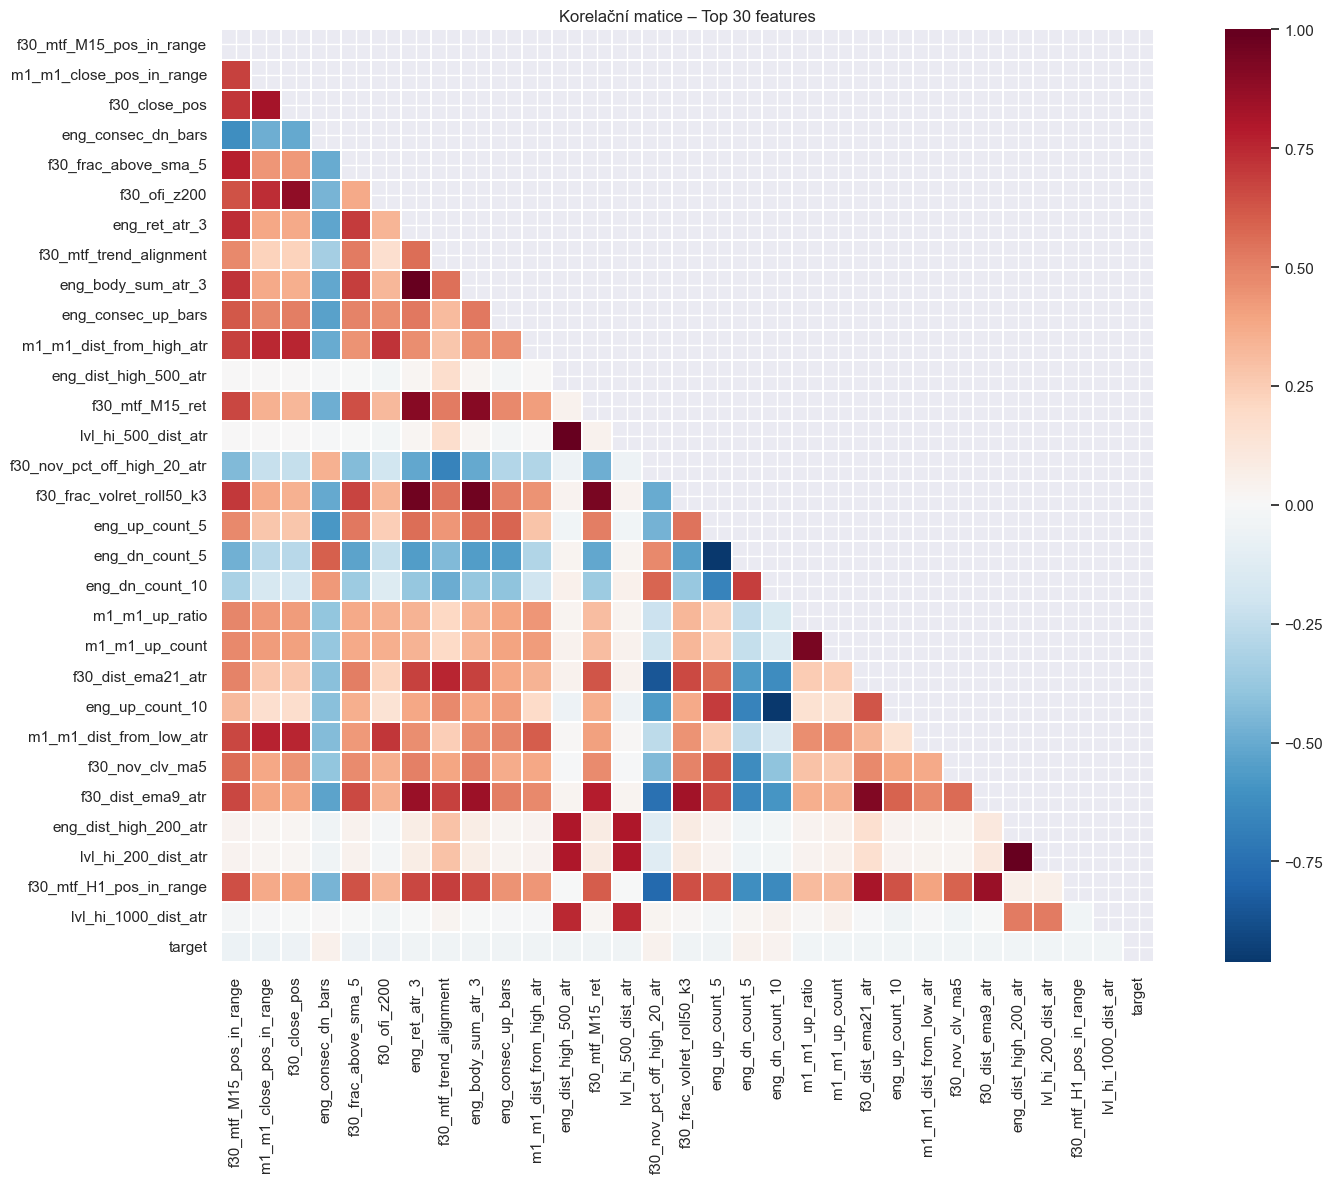


Top 10 features korelovaných s targetem:
f30_mtf_M15_pos_in_range    0.061949
m1_m1_close_pos_in_range    0.060579
f30_close_pos               0.056974
eng_consec_dn_bars          0.054522
f30_frac_above_sma_5        0.052041
f30_ofi_z200                0.050829
eng_ret_atr_3               0.050303
f30_mtf_trend_alignment     0.049665
eng_body_sum_atr_3          0.049143
eng_consec_up_bars          0.048329
dtype: float64


In [ ]:
corr_with_target = df.corrwith(df['target']).abs().sort_values(ascending=False)
top_features = corr_with_target.drop('target', errors='ignore').head(30).index.tolist()

corr_matrix = df[top_features + ['target']].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=False, square=True, linewidths=0.3)
plt.title('Korelační matice – Top 30 features')
plt.tight_layout()
plt.show()

print('\nTop 10 features korelovaných s targetem:')
print(corr_with_target.drop('target', errors='ignore').head(10))

## 7. Distribuce klíčových features (Long vs Short)

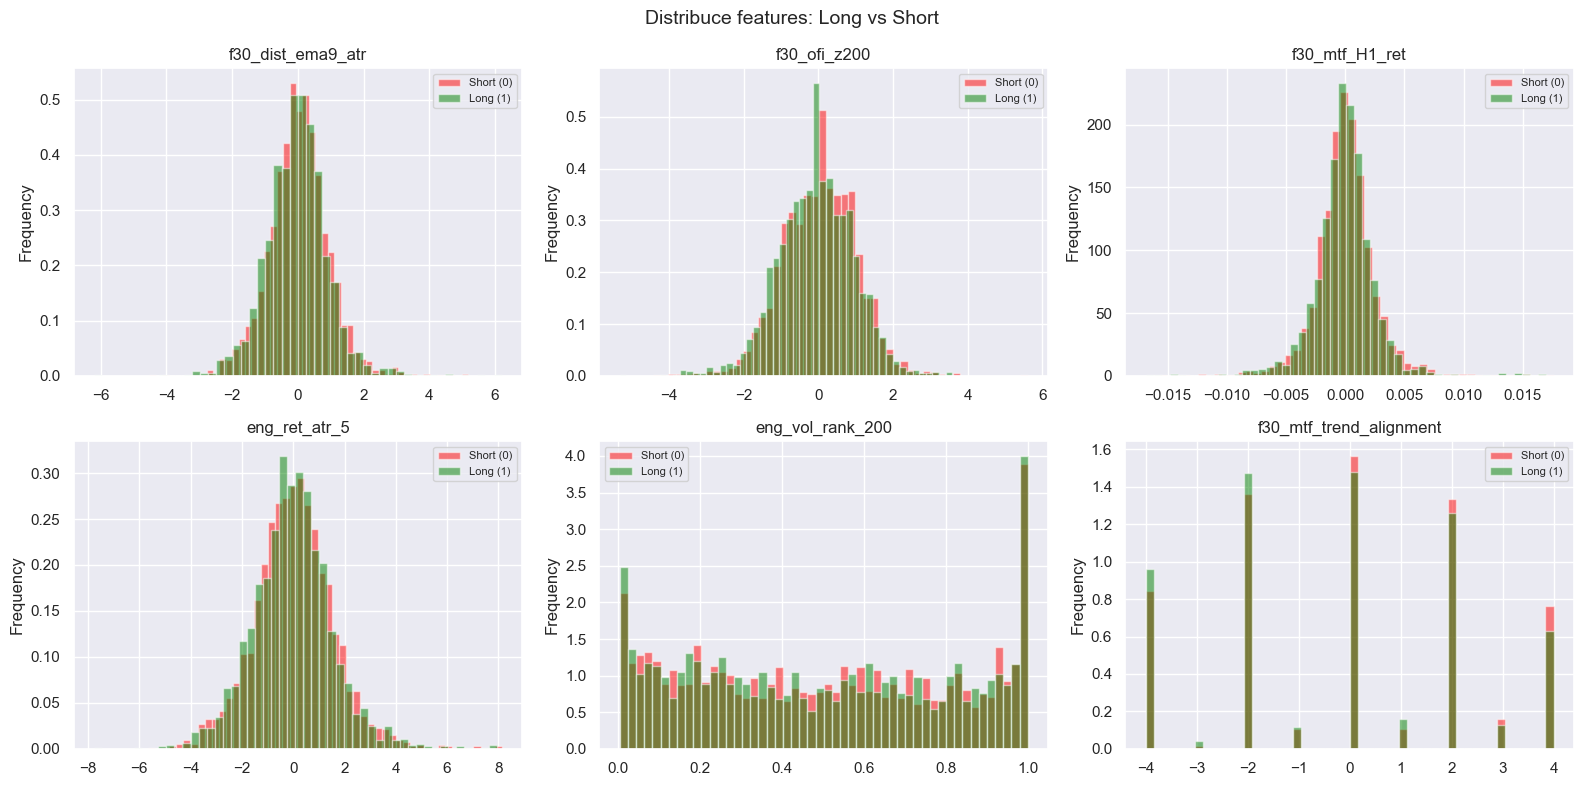

In [ ]:
key_features = [
    'f30_dist_ema9_atr', 'f30_ofi_z200', 'f30_mtf_H1_ret',
    'eng_ret_atr_5', 'eng_vol_rank_200', 'f30_mtf_trend_alignment'
]
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    df[df['target'] == 0][feat].plot.hist(
        ax=axes[i], bins=50, alpha=0.5, color='red', label='Short (0)', density=True)
    df[df['target'] == 1][feat].plot.hist(
        ax=axes[i], bins=50, alpha=0.5, color='green', label='Long (1)', density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuce features: Long vs Short', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Sezónní vzory (hodina dne, den v týdnu)

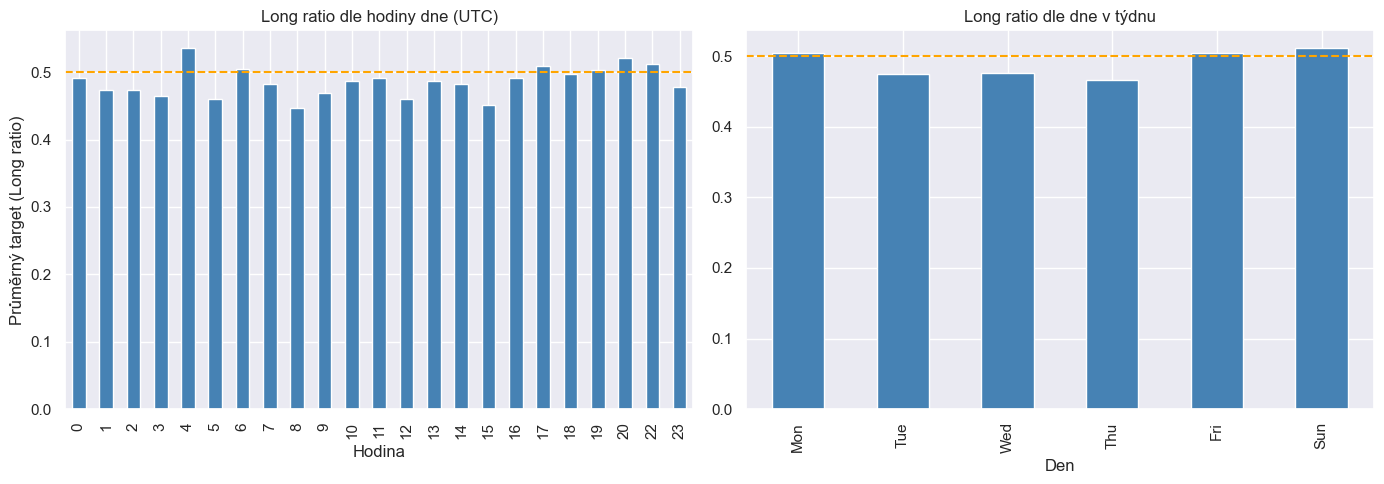

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

hourly = df.groupby(df.index.hour)['target'].mean()
hourly.plot.bar(ax=ax1, color='steelblue')
ax1.axhline(0.5, color='orange', linestyle='--')
ax1.set_title('Long ratio dle hodiny dne (UTC)')
ax1.set_xlabel('Hodina')
ax1.set_ylabel('Průměrný target (Long ratio)')

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df.groupby(df.index.dayofweek)['target'].mean()
daily.index = [dow_names[i] for i in daily.index]
daily.plot.bar(ax=ax2, color='steelblue')
ax2.axhline(0.5, color='orange', linestyle='--')
ax2.set_title('Long ratio dle dne v týdnu')
ax2.set_xlabel('Den')

plt.tight_layout()
plt.show()